# Supplementary Material S5: Classroom Pilot Statistical Analysis

## SCAFFOLD Framework Feasibility and Impact Study

**Analysis of N=27 students across 9 groups**

This notebook provides the complete statistical analysis supporting the findings reported in the main paper regarding the classroom pilot of the SCAFFOLD framework for LLM-mediated collaborative learning.

## Setup and Data Loading

### Required Libraries

This notebook uses both Python and R. Install required packages:

```bash
# Python packages
pip install pandas numpy matplotlib seaborn scipy rpy2

# R packages (run in R)
install.packages(c("tidyverse", "lme4", "lmerTest", "sjPlot", "performance", "sandwich", "lmtest"))
```

In [1]:
# Python imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

# Set up R integration
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.packages import importr

# Load rpy2 IPython extension for %%R magic
%load_ext rpy2.ipython

# Suppress warnings
warnings.filterwarnings('ignore')

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully")
print("✓ R integration ready")

Error importing in API mode: ImportError("dlopen(/opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <05EE76C0-33BF-3D4C-BC56-84005241BC88> /opt/miniconda3/envs/LLM_Frame_Paper_analysis/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


✓ Libraries loaded successfully
✓ R integration ready


In [2]:
%%R
# Load R libraries
suppressPackageStartupMessages({
    library(tidyverse)
    library(lme4)
    library(lmerTest)
    library(sjPlot)
    library(performance)
    library(sandwich)
    library(lmtest)
    library(broom.mixed)
})

cat("✓ R libraries loaded successfully\n")

✓ R libraries loaded successfully


### Data Loading and Preparation

We load three main datasets:
1. **Knowledge scores** (T1, T4, T7, T8): Student responses to microcontroller questions
2. **Engagement data**: Student feedback and group assignments
3. **Co-creation levels**: Group-level coding of student participation

In [3]:
# Load data files
data_path = Path('../Data_analysis/Data')

# 1. Children knowledge data (T1, T4, T7, T8)
df_children = pd.read_csv(data_path / 'Qualtrics/BuildBots_children_T1T4T7T8.csv')

# 2. Engagement data for group assignments and feedback
df_engagement = pd.read_csv(data_path / 'Qualtrics/BuildBots_engagement_children_T1-T7.csv', 
                            encoding='ISO-8859-1')

# 3. Group-level co-creation data
df_cocreation = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# Clean Participant IDs before passing to R (prevents conversion warnings)
df_engagement['Participant ID'] = pd.to_numeric(df_engagement['Participant ID'], errors='coerce')
df_children['Participant ID'] = pd.to_numeric(df_children['Participant ID'], errors='coerce')
df_engagement = df_engagement.dropna(subset=['Participant ID'])
df_children = df_children.dropna(subset=['Participant ID'])

print(f"✓ Data loaded")
print(f"  Children data: {df_children.shape}")
print(f"  Engagement data: {df_engagement.shape}")
print(f"  Co-creation data: {df_cocreation.shape}")
print(f"  Timepoints: {df_children['Timepoint'].unique()}")

✓ Data loaded
  Children data: (112, 95)
  Engagement data: (194, 34)
  Co-creation data: (11, 43)
  Timepoints: ['T1' 'T4' 'T7' 'T8']


## Data Preparation

### Merge datasets and create knowledge scores

**Scoring convention:**
- Correct answer (1) → 1 point
- Incorrect answer (0) → 0 points
- "I don't know" (99) → 0 points

**Two score variables:**
- **score2q:** 2 basic microcontroller questions (0-2) - Available at ALL timepoints
- **score10q:** 10 total questions = 2 basic + 8 LLM-specific (0-10) - Available at T7/T8 ONLY

In [4]:
%%R -i df_children,df_engagement,df_cocreation

# Get participant to group mapping
mapping <- df_engagement %>%
  select(`Participant ID`, Group) %>%
  distinct() %>%
  mutate(
    `Participant ID` = as.numeric(`Participant ID`),
    Group = as.numeric(Group)
  ) %>%
  filter(!is.na(`Participant ID`), !is.na(Group))

# Extract co-creation column
cocreation_col <- "Co-creation Level (0:LLM did it all, 1: concepts by students/rest llm, 2: concepts by the students, co-creation of the mnemonic, 3: mainly by students)"

df_cocreation_clean <- df_cocreation %>%
  select(Group, Cocreation_Level = all_of(cocreation_col)) %>%
  filter(!is.na(Group), !is.na(Cocreation_Level)) %>%
  mutate(Group = as.numeric(Group))

# Merge all data
df_merged <- df_children %>%
  mutate(`Participant ID` = as.numeric(`Participant ID`)) %>%
  left_join(mapping, by = "Participant ID") %>%
  filter(!is.na(Group)) %>%
  left_join(df_cocreation_clean, by = "Group") %>%
  filter(!is.na(Cocreation_Level))

cat("✓ Data merged successfully\n")
cat(sprintf("  Students: %d\n", n_distinct(df_merged$`Participant ID`)))
cat(sprintf("  Groups: %d\n", n_distinct(df_merged$Group)))

✓ Data merged successfully
  Students: 27
  Groups: 9


In [30]:
%%R

# STEP 1: Score the 2 basic microcontroller questions (ALL timepoints)
df_scored <- df_merged %>%
  mutate(
    mc1_raw = as.numeric(microcontrollers_1),
    mc2_raw = as.numeric(microcontrollers_2),
    
    # Score: 1 if correct, 0 if incorrect or "don't know" (99)
    mc1_score = if_else(mc1_raw == 1, 1, 0),
    mc2_score = if_else(mc2_raw == 1, 1, 0),
    
    # score2q: 2 basic questions (0-2) - ALL timepoints
    score2q = mc1_score + mc2_score
  )

# STEP 2: Score the 8 LLM-specific questions (T7 and T8 ONLY)
# These questions were only asked after the LLM interaction
llm_cols <- paste0("LLM_Microcontrollers_", 1:8)

# Score each LLM question
for (i in 1:8) {
  col_name <- paste0("LLM_Microcontrollers_", i)
  score_name <- paste0("llm_mc", i, "_score")
  
  df_scored <- df_scored %>%
    mutate(
      !!score_name := case_when(
        is.na(as.numeric(.data[[col_name]])) ~ NA_real_,
        as.numeric(.data[[col_name]]) == 1 ~ 1,
        as.numeric(.data[[col_name]]) %in% c(0, 99) ~ 0,
        TRUE ~ NA_real_
      )
    )
}

# STEP 3: Calculate score10q (T7/T8 only)
df_scored <- df_scored %>%
  mutate(
    # Sum of all 8 LLM questions
    llm_score8 = llm_mc1_score + llm_mc2_score + llm_mc3_score + llm_mc4_score +
                 llm_mc5_score + llm_mc6_score + llm_mc7_score + llm_mc8_score,
    
    # score10q: 2 basic + 8 LLM (0-10, T7/T8 only)
    score10q = case_when(
      Timepoint %in% c("T7", "T8") & !is.na(score2q) & !is.na(llm_score8) ~ score2q + llm_score8,
      TRUE ~ NA_real_
    )
  )

# STEP 4: Create factors
df_scored <- df_scored %>%
  mutate(
    Group_factor = factor(Group),
    Student_ID = factor(`Participant ID`),
    Timepoint_factor = factor(Timepoint, levels = c("T1", "T4", "T7", "T8")),
    Cocreation_Level = as.numeric(Cocreation_Level)
  )

cat("\n✓ Knowledge scores created:\n")
cat("  score2q: 2 basic questions (0-2) - T1, T4, T7, T8\n")
cat("  score10q: 10 total questions (0-10) - T7, T8 only\n")
cat(sprintf("\nSample: %d students, %d groups\n", 
            n_distinct(df_scored$Student_ID), 
            n_distinct(df_scored$Group_factor)))


✓ Knowledge scores created:
  score2q: 2 basic questions (0-2) - T1, T4, T7, T8
  score10q: 10 total questions (0-10) - T7, T8 only

Sample: 27 students, 9 groups


## Descriptive Statistics

### Sample Characteristics

In [32]:
%%R

cat("\n=== SAMPLE CHARACTERISTICS ===\n\n")

# Demographics (extract unique students across all timepoints)
demographics <- df_scored %>%
  group_by(Student_ID) %>%
  slice(1) %>%  # Take first observation per student
  ungroup() %>%
  summarise(
    N_total = n_distinct(Student_ID),
    Age_mean = mean(age, na.rm = TRUE),
    Age_sd = sd(age, na.rm = TRUE),
    N_female = sum(Gender == 2, na.rm = TRUE),
    N_male = sum(Gender == 1, na.rm = TRUE),
    N_other = sum(!Gender %in% c(1, 2), na.rm = TRUE)
  )

cat(sprintf("Total Sample: N = %d students\n", demographics$N_total))
cat(sprintf("Age: M = %.2f years (SD = %.2f)\n", demographics$Age_mean, demographics$Age_sd))
cat(sprintf("Gender: %d female, %d male (%.1f%%), %d other/not specified\n\n", 
            demographics$N_female, demographics$N_male, 
            (demographics$N_male / demographics$N_total) * 100,
            demographics$N_other))

# Sample size and scores by timepoint
sample_summary <- df_scored %>%
  group_by(Timepoint_factor) %>%
  summarise(
    N_students = n_distinct(Student_ID),
    N_groups = n_distinct(Group_factor),
    Mean_2q = mean(score2q, na.rm = TRUE),
    SD_2q = sd(score2q, na.rm = TRUE),
    Mean_10q = mean(score10q, na.rm = TRUE),
    SD_10q = sd(score10q, na.rm = TRUE)
  )

print(knitr::kable(sample_summary, digits = 2, 
                   caption = "Sample Size and Knowledge Scores by Timepoint"))

# Co-creation level distribution
cat("\n=== CO-CREATION LEVEL DISTRIBUTION ===\n\n")
cocreation_dist <- df_scored %>%
  filter(Timepoint == "T7") %>%
  group_by(Cocreation_Level) %>%
  summarise(
    N_students = n(),
    N_groups = n_distinct(Group_factor)
  )

print(knitr::kable(cocreation_dist, 
                   caption = "Distribution of Students by Co-creation Level"))


=== SAMPLE CHARACTERISTICS ===

Total Sample: N = 27 students
Age: M = 13.46 years (SD = 0.81)
Gender: 4 female, 21 male (77.8%), 2 other/not specified



Table: Sample Size and Knowledge Scores by Timepoint

|Timepoint_factor | N_students| N_groups| Mean_2q| SD_2q| Mean_10q| SD_10q|
|:----------------|----------:|--------:|-------:|-----:|--------:|------:|
|T1               |         26|        9|    0.46|  0.71|      NaN|     NA|
|T4               |         25|        9|    0.79|  0.59|      NaN|     NA|
|T7               |         24|        9|    0.71|  0.75|     6.12|   2.13|
|T8               |         23|        9|    0.83|  0.58|     5.26|   2.00|

=== CO-CREATION LEVEL DISTRIBUTION ===



Table: Distribution of Students by Co-creation Level

| Cocreation_Level| N_students| N_groups|
|----------------:|----------:|--------:|
|              0.0|          3|        1|
|              0.5|          9|        4|
|              1.0|          6|        2|
|              3.0|        

---

# Finding 1: Students Were More Active with SCAFFOLD Framework

**Key Result:** Students actively contributed to mnemonic creation with SCAFFOLD:
- **18 concept suggestions** in Phase 1 (identifying concepts to use)
- **13 relevant contributions** in Phase 2 (creating the mnemonic)

In contrast, students were completely passive without the framework.

## Student Contributions Analysis

The following analysis shows how students contributed across the two phases of the mnemonic creation task.

In [7]:
# Load contribution data from BuildbotAnalysis
df_contributions = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# Extract relevant columns
contribution_data = df_contributions[['Group', 
                                      'Phase 1: Number of concepts proposed by students',
                                      'Phase 2: Number of relevant Student contributions']].copy()

# Clean and convert to numeric
contribution_data = contribution_data.dropna(subset=['Group'])
contribution_data['Phase 1: Number of concepts proposed by students'] = pd.to_numeric(
    contribution_data['Phase 1: Number of concepts proposed by students'], errors='coerce')
contribution_data['Phase 2: Number of relevant Student contributions'] = pd.to_numeric(
    contribution_data['Phase 2: Number of relevant Student contributions'], errors='coerce')

# Calculate totals
total_phase1 = contribution_data['Phase 1: Number of concepts proposed by students'].sum()
total_phase2 = contribution_data['Phase 2: Number of relevant Student contributions'].sum()

print("\n=== STUDENT CONTRIBUTIONS WITH SCAFFOLD ===\n")
print(f"Phase 1 - Concept Suggestions: {int(total_phase1)}")
print(f"Phase 2 - Mnemonic Creation Contributions: {int(total_phase2)}")
print(f"Total Student Contributions: {int(total_phase1 + total_phase2)}")


=== STUDENT CONTRIBUTIONS WITH SCAFFOLD ===

Phase 1 - Concept Suggestions: 18
Phase 2 - Mnemonic Creation Contributions: 13
Total Student Contributions: 31


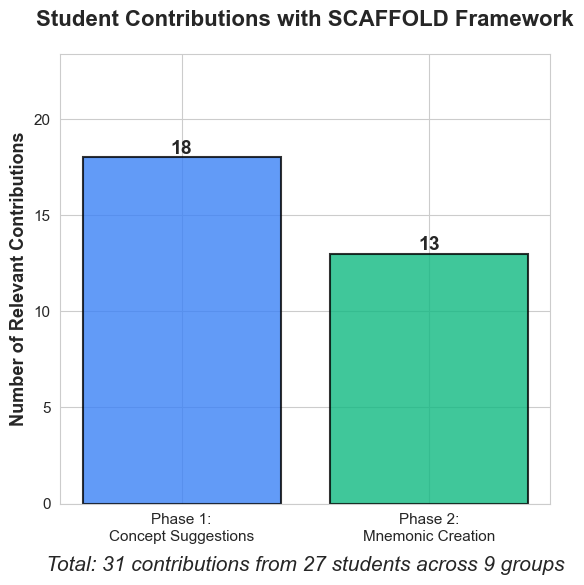


✓ With SCAFFOLD: 31 relevant contributions
✗ Without SCAFFOLD: Students were completely passive (0 contributions)


In [35]:
# Visualization: Student contributions by phase and framework condition
fig, ax = plt.subplots(figsize=(8, 6))

# Data for grouped bar chart
conditions = ['Without\nFrame', 'With\nFrame']
phase1_data = [0, total_phase1]  # Phase 1: 0 without, actual count with
phase2_data = [0, total_phase2]  # Phase 2: 0 without, actual count with

x = np.arange(len(conditions))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, phase1_data, width, label='Phase 1: Concept Suggestions', 
               color='#3b82f6', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, phase2_data, width, label='Phase 2: Mnemonic Creation', 
               color='#10b981', alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_title('Student Contributions: Without vs With SCAFFOLD Framework', 
             fontweight='bold', fontsize=16, pad=20)
ax.set_ylabel('Number of Relevant Contributions', fontsize=13, fontweight='bold')
ax.set_xlabel('Framework Condition', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=12)
ax.set_ylim(0, max(total_phase1, total_phase2) * 1.3)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=13, fontweight='bold')

# Add description
ax.text(0.5, -0.18, 
        f'Sample: 27 students across 9 groups',
        transform=ax.transAxes, ha='center', fontsize=11, style='italic')

plt.tight_layout()
plt.show()

print(f"\n✓ With SCAFFOLD: {int(total_phase1 + total_phase2)} relevant contributions")
print("✗ Without SCAFFOLD: Students were completely passive (0 contributions)")

---

# Finding 2: More Active Students Show Higher Post-Test Knowledge Scores

**Research Question 1:** To what extent did the frame support children's short-term and long-term learning?

## Analysis: Co-creation Level → Knowledge Scores (T7 and T8)

We use **mixed-effects models** (or cluster-robust standard errors) to account for the nested structure (students within groups) while testing whether co-creation level predicts knowledge scores.

**Note:** For T7/T8 analyses, we use **score10q** (all 10 microcontroller questions).

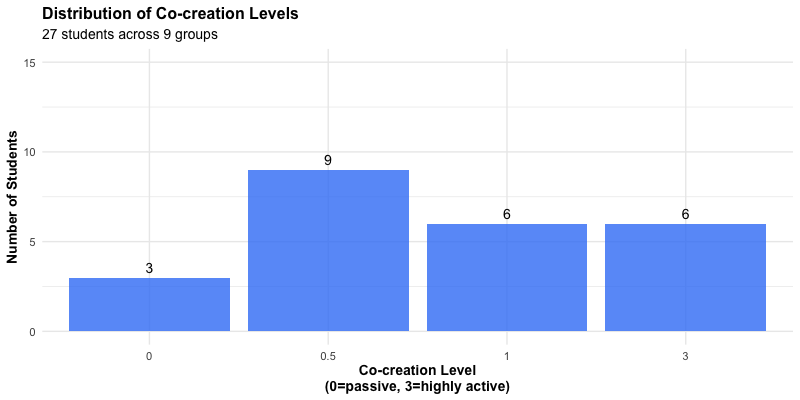

In [9]:
%%R -w 800 -h 400 --units px

# Visualize co-creation level distribution
df_t7 <- df_scored %>% filter(Timepoint == "T7")

ggplot(df_t7, aes(x = factor(Cocreation_Level))) +
  geom_bar(fill = "#3b82f6", alpha = 0.8) +
  geom_text(stat = 'count', aes(label = after_stat(count)), vjust = -0.5, size = 5) +
  labs(
    title = "Distribution of Co-creation Levels",
    subtitle = "27 students across 9 groups",
    x = "Co-creation Level\n(0=passive, 3=highly active)",
    y = "Number of Students"
  ) +
  scale_y_continuous(limits = c(0, 15)) +
  theme_minimal(base_size = 14) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.title = element_text(face = "bold")
  )

### Model 1: Co-creation → Immediate Post-Test (T7)

**Model:** Mixed-effects model `score10q_T7 ~ Co-creation_Level + (1|Group)`

In [10]:
%%R

# Model 1: Co-creation predicts T7 knowledge (10 questions)
df_t7 <- df_scored %>% filter(Timepoint == "T7")

# Mixed-effects model with random intercept for Group
model1_lmer <- lmer(score10q ~ Cocreation_Level + (1|Group_factor), data = df_t7)

cat("\n=== MODEL 1: Mixed-Effects - Co-creation → T7 Knowledge (10 questions) ===\n\n")
print(summary(model1_lmer))

# Extract key statistics
beta_t7 <- fixef(model1_lmer)["Cocreation_Level"]
coef_table <- summary(model1_lmer)$coefficients
p_val_t7 <- coef_table["Cocreation_Level", "Pr(>|t|)"]

cat("\n--- Interpretation ---\n")
cat(sprintf("Fixed Effect (β): %.3f\n", beta_t7))
cat(sprintf("p-value: %.4f\n", p_val_t7))

if (p_val_t7 < 0.05) {
  cat("\n✓ SIGNIFICANT: Higher co-creation predicts better T7 knowledge\n")
  cat(sprintf("  Each level increase in co-creation → +%.2f points (%.0f%% improvement)\n", 
              beta_t7, beta_t7/10*100))
} else {
  cat("\n× NOT SIGNIFICANT at α=0.05\n")
}

# Simple correlation with p-value
cat("\n--- Correlation Analysis ---\n")
cor_test_t7 <- cor.test(df_t7$Cocreation_Level, df_t7$score10q, method = "pearson")
cat(sprintf("Pearson correlation: r = %.3f, p = %.4f\n", 
            cor_test_t7$estimate, cor_test_t7$p.value))


=== MODEL 1: Mixed-Effects - Co-creation → T7 Knowledge (10 questions) ===

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: score10q ~ Cocreation_Level + (1 | Group_factor)
   Data: df_t7

REML criterion at convergence: 93.6

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.47612 -0.68164  0.09132  0.45945  2.08823 

Random effects:
 Groups       Name        Variance Std.Dev.
 Group_factor (Intercept) 0.000    0.000   
 Residual                 3.072    1.753   
Number of obs: 24, groups:  Group_factor, 9

Fixed effects:
                 Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)        4.7690     0.5296 22.0000   9.004 7.85e-09 ***
Cocreation_Level   1.1419     0.3289 22.0000   3.472  0.00216 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
Cocretn_Lvl -0.737
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: 

boundary (singular) fit: see help('isSingular')


#### Model 1 Diagnostics

In [11]:
%%R -w 1200 -h 1000 --units px

# Model performance
cat("\nModel Performance:\n")
performance::icc(model1_lmer)
performance::r2(model1_lmer)


Model Performance:
Random effect variances not available. Returned R2 does not account for random effects.
# R2 for Mixed Models

  Conditional R2: NA
     Marginal R2: 0.344


De plus : Messages d'avis :
1: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 
2: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 


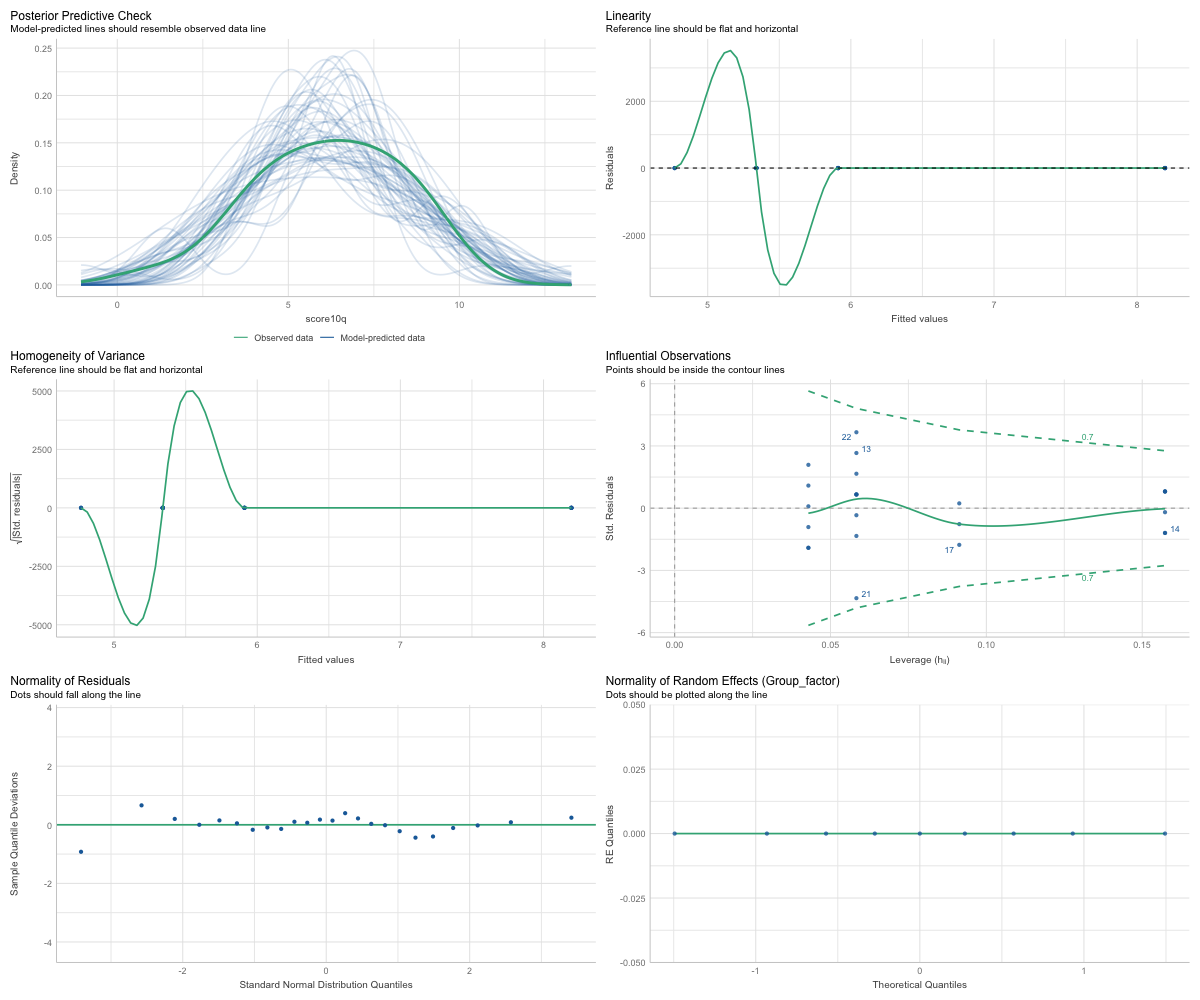

In [12]:
%%R -w 1200 -h 1000 --units px

# Comprehensive assumption checks
check_model(model1_lmer, panel = TRUE)

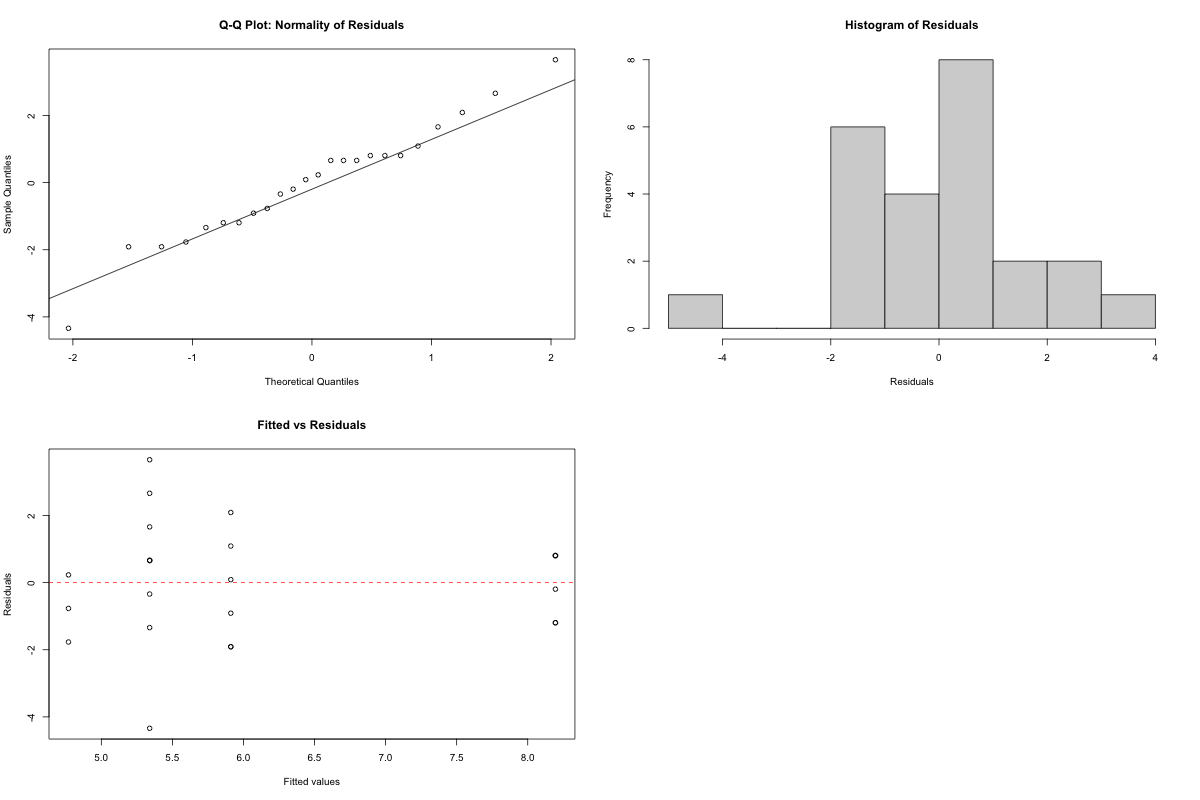

In [13]:
%%R -w 1200 -h 800 --units px

# Additional diagnostic plots
par(mfrow = c(2, 2))
plot(model1_lmer, main = "Model 1: Residuals vs Fitted")
qqnorm(resid(model1_lmer), main = "Q-Q Plot: Normality of Residuals")
qqline(resid(model1_lmer))
hist(resid(model1_lmer), main = "Histogram of Residuals", xlab = "Residuals", breaks = 10)
plot(fitted(model1_lmer), resid(model1_lmer), main = "Fitted vs Residuals", 
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, lty = 2, col = "red")
par(mfrow = c(1, 1))

### Model 2: Co-creation → Delayed Post-Test (T8)

**Model:** Mixed-effects model `score10q_T8 ~ Co-creation_Level + (1|Group)`

In [14]:
%%R

# Model 2: Co-creation predicts T8 knowledge (delayed test)
df_t8 <- df_scored %>% filter(Timepoint == "T8")

# Mixed-effects model with random intercept for Group
model2_lmer <- lmer(score10q ~ Cocreation_Level + (1|Group_factor), data = df_t8)

cat("\n=== MODEL 2: Mixed-Effects - Co-creation → T8 Knowledge (Delayed, 10 questions) ===\n\n")
print(summary(model2_lmer))

# Extract key statistics
beta_t8 <- fixef(model2_lmer)["Cocreation_Level"]
coef_table_t8 <- summary(model2_lmer)$coefficients
p_val_t8 <- coef_table_t8["Cocreation_Level", "Pr(>|t|)"]

cat("\n--- Interpretation ---\n")
cat(sprintf("Fixed Effect (β): %.3f\n", beta_t8))
cat(sprintf("p-value: %.4f\n", p_val_t8))

if (p_val_t8 < 0.05) {
  cat("\n✓ SIGNIFICANT: Co-creation benefits persist at T8\n")
  cat(sprintf("  Each level increase in co-creation → +%.2f points (%.0f%% improvement)\n", 
              beta_t8, beta_t8/10*100))
} else {
  cat("\n× NOT SIGNIFICANT at α=0.05\n")
  cat("  Co-creation benefits may not fully persist over time\n")
}

# Simple correlation with p-value
cat("\n--- Correlation Analysis ---\n")
cor_test_t8 <- cor.test(df_t8$Cocreation_Level, df_t8$score10q, method = "pearson")
cat(sprintf("Pearson correlation: r = %.3f, p = %.4f\n", 
            cor_test_t8$estimate, cor_test_t8$p.value))


=== MODEL 2: Mixed-Effects - Co-creation → T8 Knowledge (Delayed, 10 questions) ===

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: score10q ~ Cocreation_Level + (1 | Group_factor)
   Data: df_t8

REML criterion at convergence: 94.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.65756 -0.42124  0.01982  0.52832  1.54532 

Random effects:
 Groups       Name        Variance Std.Dev.
 Group_factor (Intercept) 0.000    0.000   
 Residual                 3.867    1.967   
Number of obs: 23, groups:  Group_factor, 9

Fixed effects:
                 Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)        4.6958     0.5824 21.0000   8.062 7.27e-08 ***
Cocreation_Level   0.5305     0.3883 21.0000   1.366    0.186    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
Cocretn_Lvl -0.710
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singul

boundary (singular) fit: see help('isSingular')


#### Model 2 Diagnostics

In [15]:
%%R -w 1200 -h 1000 --units px

# Model performance
cat("\nModel Performance:\n")
performance::icc(model2_lmer)
performance::r2(model2_lmer)


Model Performance:
Random effect variances not available. Returned R2 does not account for random effects.
# R2 for Mixed Models

  Conditional R2: NA
     Marginal R2: 0.078


De plus : Messages d'avis :
1: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 
2: Can't compute random effect variances. Some variance components equal
  zero. Your model may suffer from singularity (see `?lme4::isSingular`
  and `?performance::check_singularity`).
  Decrease the `tolerance` level to force the calculation of random effect
  variances, or impose priors on your random effects parameters (using
  packages like `brms` or `glmmTMB`). 


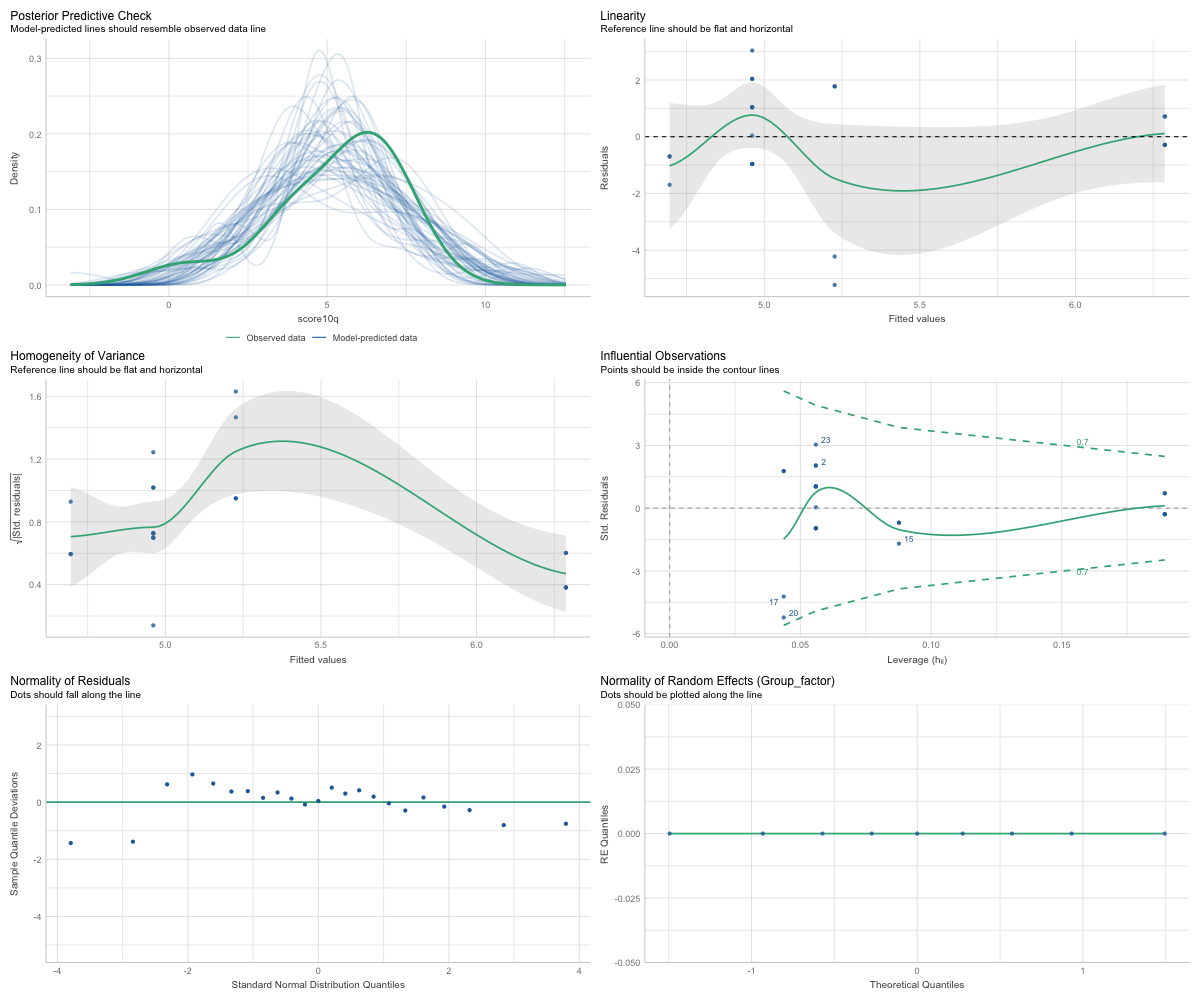

In [16]:
%%R -w 1200 -h 1000 --units px

# Comprehensive assumption checks
check_model(model2_lmer, panel = TRUE)

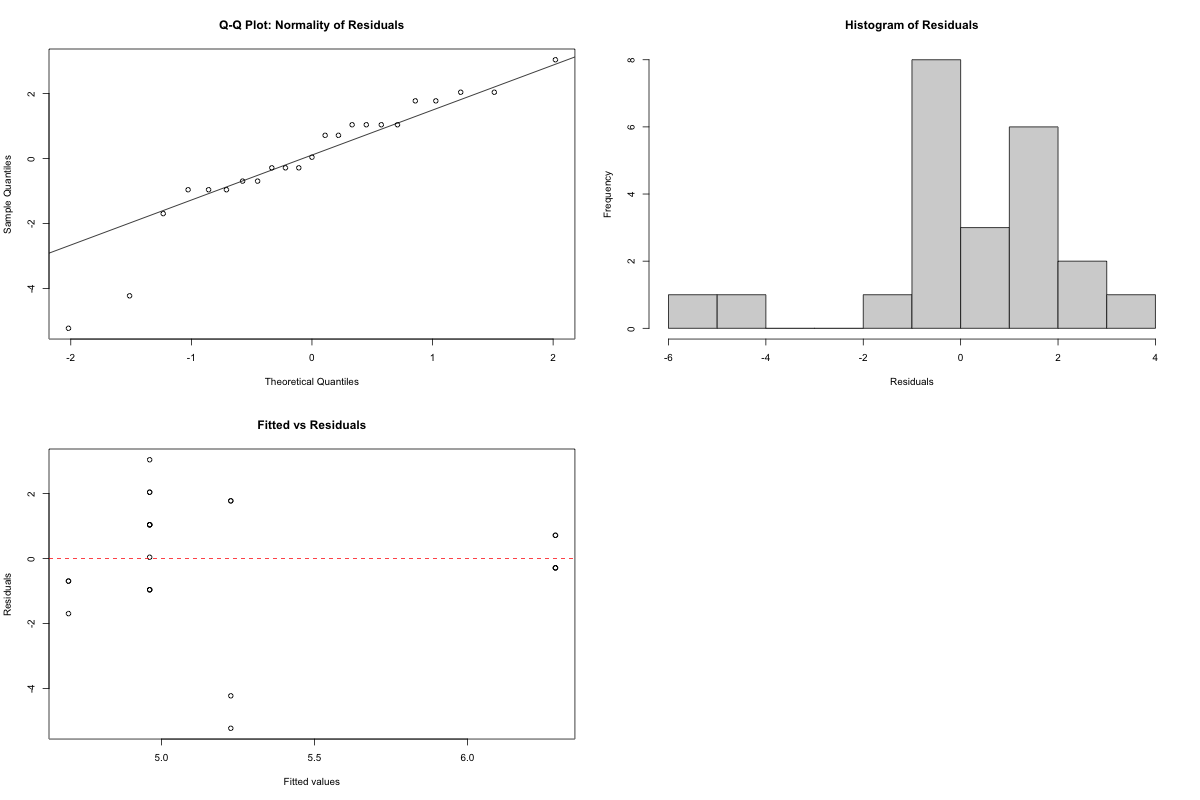

In [17]:
%%R -w 1200 -h 800 --units px

# Additional diagnostic plots
par(mfrow = c(2, 2))
plot(model2_lmer, main = "Model 2: Residuals vs Fitted")
qqnorm(resid(model2_lmer), main = "Q-Q Plot: Normality of Residuals")
qqline(resid(model2_lmer))
hist(resid(model2_lmer), main = "Histogram of Residuals", xlab = "Residuals", breaks = 10)
plot(fitted(model2_lmer), resid(model2_lmer), main = "Fitted vs Residuals", 
     xlab = "Fitted values", ylab = "Residuals")
abline(h = 0, lty = 2, col = "red")
par(mfrow = c(1, 1))

### Model 1 and 2: Visualisation Finding 2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'



Attachement du package : ‘gridExtra’

L'objet suivant est masqué depuis ‘package:dplyr’:

    combine

De plus : Message d'avis :
Removed 1 row containing missing values or values outside the scale range
(`geom_point()`). 


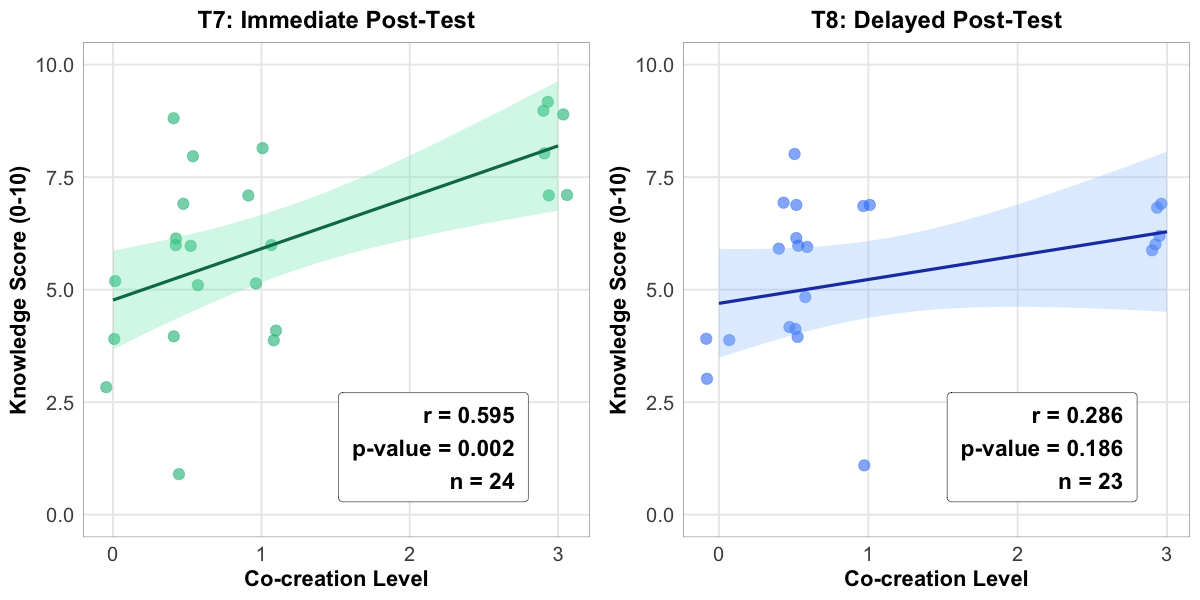

In [18]:
%%R -w 1200 -h 600 --units px

# Publication-ready visualization: Co-creation vs Knowledge at T7 and T8
library(gridExtra)

df_t7_t8 <- df_scored %>% filter(Timepoint %in% c("T7", "T8"))

# Calculate correlations and p-values for annotations
cor_t7 <- cor.test(df_t7_t8$Cocreation_Level[df_t7_t8$Timepoint == "T7"], 
                   df_t7_t8$score10q[df_t7_t8$Timepoint == "T7"], 
                   method = "pearson")
cor_t8 <- cor.test(df_t7_t8$Cocreation_Level[df_t7_t8$Timepoint == "T8"], 
                   df_t7_t8$score10q[df_t7_t8$Timepoint == "T8"], 
                   method = "pearson")

# Format p-values
p_t7_text <- ifelse(cor_t7$p.value < 0.001, "p-value: < 0.001", 
                    sprintf("p-value = %.3f", cor_t7$p.value))
p_t8_text <- ifelse(cor_t8$p.value < 0.001, "p-value: < 0.001", 
                    sprintf("p-value = %.3f", cor_t8$p.value))

# Create annotation text
annot_t7 <- sprintf("r = %.3f\n%s\nn = %d", 
                    cor_t7$estimate, p_t7_text, 
                    sum(!is.na(df_t7_t8$score10q[df_t7_t8$Timepoint == "T7"])))
annot_t8 <- sprintf("r = %.3f\n%s\nn = %d", 
                    cor_t8$estimate, p_t8_text,
                    sum(!is.na(df_t7_t8$score10q[df_t7_t8$Timepoint == "T8"])))

# Plot T7 (GREEN)
p1 <- ggplot(df_t7_t8 %>% filter(Timepoint == "T7"), 
             aes(x = Cocreation_Level, y = score10q)) +
  geom_jitter(width = 0.1, height = 0.2, alpha = 0.6, size = 5, color = "#10b981") +
  geom_smooth(method = "lm", se = TRUE, color = "#047857", fill = "#6ee7b7", 
              alpha = 0.3, linewidth = 1.5) +
  annotate("label", x = 2.8, y = 1.5, label = annot_t7, 
           hjust = 1, size = 8, fontface = "bold", 
           fill = "white", label.padding = unit(0.5, "lines")) +
  labs(
    title = "T7: Immediate Post-Test",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  scale_x_continuous(breaks = 0:3) +
  ylim(0, 10) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 24, hjust = 0.5),
    axis.title = element_text(face = "bold", size = 22),
    axis.text = element_text(size = 20),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "gray50", fill = NA, linewidth = 0.5)
  )

# Plot T8 (BLUE)
p2 <- ggplot(df_t7_t8 %>% filter(Timepoint == "T8"), 
             aes(x = Cocreation_Level, y = score10q)) +
  geom_jitter(width = 0.1, height = 0.2, alpha = 0.6, size = 5, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "#1e40af", fill = "#93c5fd", 
              alpha = 0.3, linewidth = 1.5) +
  annotate("label", x = 2.8, y = 1.5, label = annot_t8, 
           hjust = 1, size = 8, fontface = "bold", 
           fill = "white", label.padding = unit(0.5, "lines")) +
  labs(
    title = "T8: Delayed Post-Test",
    x = "Co-creation Level",
    y = "Knowledge Score (0-10)"
  ) +
  scale_x_continuous(breaks = 0:3) +
  ylim(0, 10) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = "bold", size = 24, hjust = 0.5),
    axis.title = element_text(face = "bold", size = 22),
    axis.text = element_text(size = 20),
    panel.grid.minor = element_blank(),
    panel.border = element_rect(color = "gray50", fill = NA, linewidth = 0.5)
  )

# Combine plots (title embedded in individual plots)
grid.arrange(p1, p2, ncol = 2)

---

# Finding 3: Previous Knowledge Did Not Predict Co-Creation Level

**Research Question 4:** To what extent does children's prior knowledge (T1) predict co-creation level?

**Finding:** T1 scores do **not** predict co-creation level, suggesting that engagement was independent of prior ability.

## Analysis: Baseline Knowledge (T1) → Co-creation Level

**Note:** This uses **score2q** (the only measure available at T1).

In [19]:
%%R

# Aggregate to group level (co-creation is group-level)
df_t1 <- df_scored %>% filter(Timepoint == "T1")

df_t1_group <- df_t1 %>%
  group_by(Group_factor) %>%
  summarise(
    mean_T1_score = mean(score2q, na.rm = TRUE),
    Cocreation_Level = first(Cocreation_Level)
  )

# Simple linear regression (group-level)
model_selection <- lm(Cocreation_Level ~ mean_T1_score, data = df_t1_group)

cat("\n=== MODEL: T1 Knowledge (2q) → Co-creation Level ===\n\n")
print(summary(model_selection))

beta_selection <- coef(model_selection)["mean_T1_score"]
p_selection <- summary(model_selection)$coefficients[2, 4]

cat("\n--- Interpretation ---\n")
if (p_selection < 0.05) {
  cat("⚠ SELECTION EFFECT DETECTED\n")
  cat("  Prior knowledge predicts co-creation level\n")
  cat("  → Caution needed for causal interpretation\n")
} else {
  cat("✓ NO SELECTION EFFECT\n")
  cat("  Prior knowledge does NOT predict co-creation\n")
  cat("  → Supports causal interpretation of co-creation effects\n")
}


=== MODEL: T1 Knowledge (2q) → Co-creation Level ===


Call:
lm(formula = Cocreation_Level ~ mean_T1_score, data = df_t1_group)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.1167 -0.6000 -0.6000 -0.1083  1.8917 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)     1.1000     0.5315   2.070   0.0773 .
mean_T1_score   0.0250     0.7973   0.031   0.9759  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.188 on 7 degrees of freedom
Multiple R-squared:  0.0001404,	Adjusted R-squared:  -0.1427 
F-statistic: 0.0009833 on 1 and 7 DF,  p-value: 0.9759


--- Interpretation ---
✓ NO SELECTION EFFECT
  Prior knowledge does NOT predict co-creation
  → Supports causal interpretation of co-creation effects


`geom_smooth()` using formula = 'y ~ x'


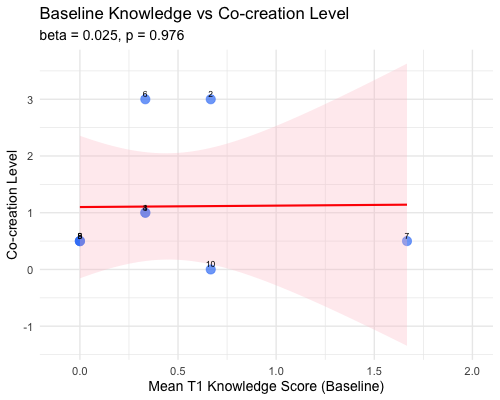

In [20]:
%%R -w 500 -h 400 --units px

# Visualization
ggplot(df_t1_group, aes(x = mean_T1_score, y = Cocreation_Level)) +
  geom_point(size = 4, alpha = 0.7, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "red", fill = "pink", alpha = 0.3) +
  geom_text(aes(label = Group_factor), nudge_y = 0.1, size = 3) +
  labs(
    title = "Baseline Knowledge vs Co-creation Level",
    subtitle = sprintf("beta = %.3f, p = %.3f", beta_selection, p_selection),
    x = "Mean T1 Knowledge Score (Baseline)",
    y = "Co-creation Level"
  ) +
  xlim(-0.1, 2) +
  theme_minimal(base_size = 14)

---

# Finding 4: More Balanced Turn-Taking with SCAFFOLD

**Research Question 2:** To what extent did the frame balance turns between students?


In [53]:
# Function to calculate Gini Coefficient (Balance Score)
# 
# Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * X̄ * n * (n-1))
# where:
#   x_i = sorted values (ascending order)
#   i = rank index (1 to n)
#   n = number of values
#   X̄ = mean of values
# 
# Range: 0 (perfect equality) to 1 (maximum inequality)
# Lower Gini = More balanced turn distribution
#
# This version excludes self-pairings and is more appropriate for small samples.
#
# Reference: Dixon, P. M., Weiner, J., Mitchell-Olds, T., & Woodley, R. (1987). 
#            Bootstrapping the Gini Coefficient of Inequality. Ecology, 68(5), 1548–1551. 
#            https://doi.org/10.2307/1939238
#      
#
def gini(list_of_values):
    values = np.array(list_of_values)
    values = values[~np.isnan(values)] # Remove NA
    if len(values) == 0 or sum(values) == 0:
        return np.nan
    sorted_values = np.sort(values)
    n = len(values)
    sum_val = np.sum(sorted_values)
    index = np.arange(1, n + 1)
    # G' formula (without self-pairing): G = Σ(2i-n-1)*x_i / (2*Σx_i*(n-1))
    return (np.sum((2 * index - n - 1) * sorted_values)) / (2 * sum_val * (n - 1))

# Load the BuildbotAnalysis data for turn distribution
df_analysis = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', skiprows=1)

# 1. Select the turn columns for each student
s_cols_no = ['No Frame: student 1', 'No Frame: student 2', 'No Frame: student 3']
s_cols_with = ['With Frame: student 1', 'With Frame: student 2', 'With Frame: student 3']

# 2. Calculate Balance Scores for each condition
df_analysis['balance_no_frame'] = df_analysis[s_cols_no].apply(lambda x: gini(x), axis=1)
df_analysis['balance_with_frame'] = df_analysis[s_cols_with].apply(lambda x: gini(x), axis=1)

# Drop rows where we don't have comparison data
df_balance = df_analysis[['Group', 'balance_no_frame', 'balance_with_frame']].dropna()

# Calculate Stats for the Graph
mean_no = df_balance['balance_no_frame'].mean()
var_no = df_balance['balance_no_frame'].var()
mean_with = df_balance['balance_with_frame'].mean()
var_with = df_balance['balance_with_frame'].var()

print("\n=== TURN BALANCE (GINI COEFFICIENT) ===\n")
print("Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * Σx_i * (n-1))")
print("where:")
print("  x_i = sorted values (ascending order)")
print("  i = rank index (1 to n)")
print("  n = number of values")
print("Range: 0 (perfect equality) to 1 (maximum inequality)")
print("Reference: Dixon et al. (1987), Ecology, 68(5), 1548-1551\n")
print(f"Without Frame: G_mean = {mean_no:.2f}, G_var = {var_no:.3f}")
print(f"With Frame: G_mean = {mean_with:.2f}, G_var = {var_with:.3f}")
print(f"\nLower Gini = More balanced turn distribution")


=== TURN BALANCE (GINI COEFFICIENT) ===

Formula (G', without self-pairing): G = Σ(2i - n - 1) * x_i / (2 * Σx_i * (n-1))
where:
  x_i = sorted values (ascending order)
  i = rank index (1 to n)
  n = number of values
Range: 0 (perfect equality) to 1 (maximum inequality)
Reference: Dixon et al. (1987), Ecology, 68(5), 1548-1551

Without Frame: G_mean = 0.28, G_var = 0.046
With Frame: G_mean = 0.15, G_var = 0.008

Lower Gini = More balanced turn distribution


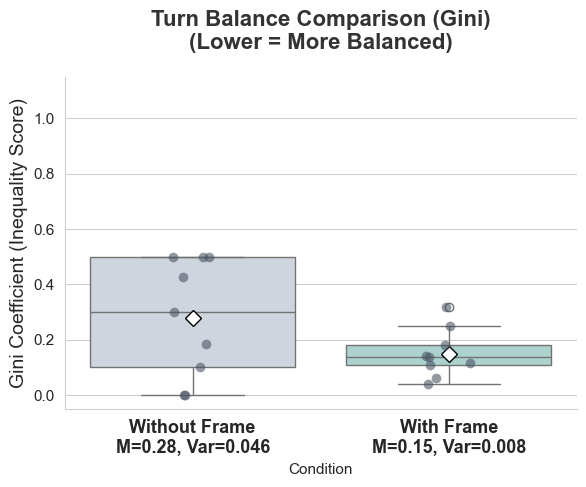


=== WILCOXON SIGNED-RANK TEST (Central Tendency) ===

Statistic: 9.00
p-value: 0.1289

✗ No significant difference in turn balance (p >= 0.05)

=== F-TEST FOR EQUALITY OF VARIANCES (Reliability) ===

Variance Without Frame: 0.0458
Variance With Frame: 0.0078
F-statistic: 5.84
p-value: 0.0221

✓ Significant difference in variance (p < 0.05)
  → Frame condition shows more consistent turn balance


In [56]:
# Visualization: Gini Coefficient Comparison
from scipy.stats import wilcoxon

plt.figure(figsize=(6, 5))
color_baseline = "#CBD5E1" # Pastel Grey
color_frame    = "#A5D8D0" # Soft Aqua

# Reshape for plotting
df_plot = df_balance.melt(id_vars='Group', var_name='Condition', value_name='Gini')
df_plot['Condition'] = df_plot['Condition'].map({
    'balance_no_frame': 'Without Frame', 
    'balance_with_frame': 'With Frame'
})

# Create boxplot showing the mean as a white diamond
ax = sns.boxplot(data=df_plot, x='Condition', y='Gini', 
                 palette=[color_baseline, color_frame],
                 showmeans=True,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"},
                 legend=False)

sns.stripplot(data=df_plot, x='Condition', y='Gini', color='#4B5563', alpha=0.6, size=7)

# Update X-axis labels to include Mean and Variance
plt.xticks(ticks=[0, 1], labels=[
    f"Without Frame\nM={mean_no:.2f}, Var={var_no:.3f}",
    f"With Frame\nM={mean_with:.2f}, Var={var_with:.3f}"
], fontsize=13, fontweight='bold')

plt.title("Turn Balance Comparison (Gini)\n(Lower = More Balanced)", fontweight='bold', fontsize=16, pad=20, color='#333333')
plt.ylabel("Gini Coefficient (Inequality Score)", fontsize=14)
plt.ylim(-0.05, 1.15)

# Calculate statistical tests for annotation
stat_w, p_w = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
var_no_temp = df_balance['balance_no_frame'].var()
var_with_temp = df_balance['balance_with_frame'].var()
n_no_temp = len(df_balance['balance_no_frame'])
n_with_temp = len(df_balance['balance_with_frame'])
F_stat_temp = var_no_temp / var_with_temp if var_no_temp > var_with_temp else var_with_temp / var_no_temp
df1_temp = n_no_temp - 1 if var_no_temp > var_with_temp else n_with_temp - 1
df2_temp = n_with_temp - 1 if var_no_temp > var_with_temp else n_no_temp - 1
from scipy.stats import f as f_dist
p_f = 2 * (1 - f_dist.cdf(F_stat_temp, df1_temp, df2_temp))

# Add statistical test results as text annotation on graph
sig_wilcox = '**' if p_w < 0.01 else '*' if p_w < 0.05 else 'ns'
sig_f = '**' if p_f < 0.01 else '*' if p_f < 0.05 else 'ns'
stats_text = f"Wilcoxon: p={p_w:.4f} {sig_wilcox}\nF-test (var): p={p_f:.4f} {sig_f}"
plt.text(0.98, 0.97, stats_text, transform=ax.transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#999999'))

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Statistical Testing
# 1. Wilcoxon test for difference in central tendency (median)
stat_w, p_w = wilcoxon(df_balance['balance_no_frame'], df_balance['balance_with_frame'])
print(f"\n=== WILCOXON SIGNED-RANK TEST (Central Tendency) ===\n")
print(f"Statistic: {stat_w:.2f}")
print(f"p-value: {p_w:.4f}")
if p_w < 0.05:
    print("\n✓ Significant difference in turn balance (p < 0.05)")
else:
    print("\n✗ No significant difference in turn balance (p >= 0.05)")

# 2. F-test for difference in variance (reliability/consistency)
var_no = df_balance['balance_no_frame'].var()
var_with = df_balance['balance_with_frame'].var()
n_no = len(df_balance['balance_no_frame'])
n_with = len(df_balance['balance_with_frame'])

# F-statistic: ratio of variances (larger/smaller)
F_stat = var_no / var_with if var_no > var_with else var_with / var_no
df1 = n_no - 1 if var_no > var_with else n_with - 1
df2 = n_with - 1 if var_no > var_with else n_no - 1

from scipy.stats import f
p_f = 2 * (1 - f.cdf(F_stat, df1, df2))  # Two-tailed test

print(f"\n=== F-TEST FOR EQUALITY OF VARIANCES (Reliability) ===\n")
print(f"Variance Without Frame: {var_no:.4f}")
print(f"Variance With Frame: {var_with:.4f}")
print(f"F-statistic: {F_stat:.2f}")
print(f"p-value: {p_f:.4f}")
if p_f < 0.05:
    print("\n✓ Significant difference in variance (p < 0.05)")
    print("  → Frame condition shows more consistent turn balance")
else:
    print("\n✗ No significant difference in variance (p >= 0.05)")

---

# Finding 5: Dramatically Fewer Off-Topic Turns

**Key Result (from Finding 4 analysis above):** 
- **With SCAFFOLD:** ~99% on-topic turns
- **Without SCAFFOLD:** ~62% on-topic turns

This suggests students were more engaged and focused with the framework.

In [52]:
# Load turn-taking data from comparison file
comparison_cols = ['Group', 'Number of Turns in Frame', 'Number of Turns in No Frame',
                   'Out of topic turns  with frame', 'Out of topic turns without Frame']

df_turns = pd.read_csv(data_path / 'BuildbotAnalysis - LLM analysis.csv', 
                       skiprows=1, usecols=comparison_cols)

df_turns = df_turns.dropna(subset=['Group'])
# Remove summary rows like 'Grand Total'
df_turns = df_turns[df_turns['Group'].apply(lambda x: str(x).replace('.', '', 1).isdigit())]
df_turns['Group'] = df_turns['Group'].astype(int)

# Calculate totals
total_turns_frame = df_turns['Number of Turns in Frame'].sum()
total_turns_no_frame = df_turns['Number of Turns in No Frame'].sum()
off_topic_frame = df_turns['Out of topic turns  with frame'].sum()
off_topic_no_frame = df_turns['Out of topic turns without Frame'].sum()

print("\n=== TURN-TAKING STATISTICS ===\n")
print(f"Total turns WITH SCAFFOLD: {total_turns_frame:.0f}")
print(f"Total turns WITHOUT SCAFFOLD: {total_turns_no_frame:.0f}")
print(f"\nOff-topic WITH SCAFFOLD: {off_topic_frame:.0f} ({off_topic_frame/total_turns_frame*100:.1f}%)")
print(f"Off-topic WITHOUT SCAFFOLD: {off_topic_no_frame:.0f} ({off_topic_no_frame/total_turns_no_frame*100:.1f}%)")
print(f"\n✓ On-topic WITH SCAFFOLD: {100 - off_topic_frame/total_turns_frame*100:.0f}%")
print(f"  On-topic WITHOUT SCAFFOLD: {100 - off_topic_no_frame/total_turns_no_frame*100:.0f}%")


=== TURN-TAKING STATISTICS ===

Total turns WITH SCAFFOLD: 104
Total turns WITHOUT SCAFFOLD: 79

Off-topic WITH SCAFFOLD: 1 (1.0%)
Off-topic WITHOUT SCAFFOLD: 30 (38.0%)

✓ On-topic WITH SCAFFOLD: 99%
  On-topic WITHOUT SCAFFOLD: 62%


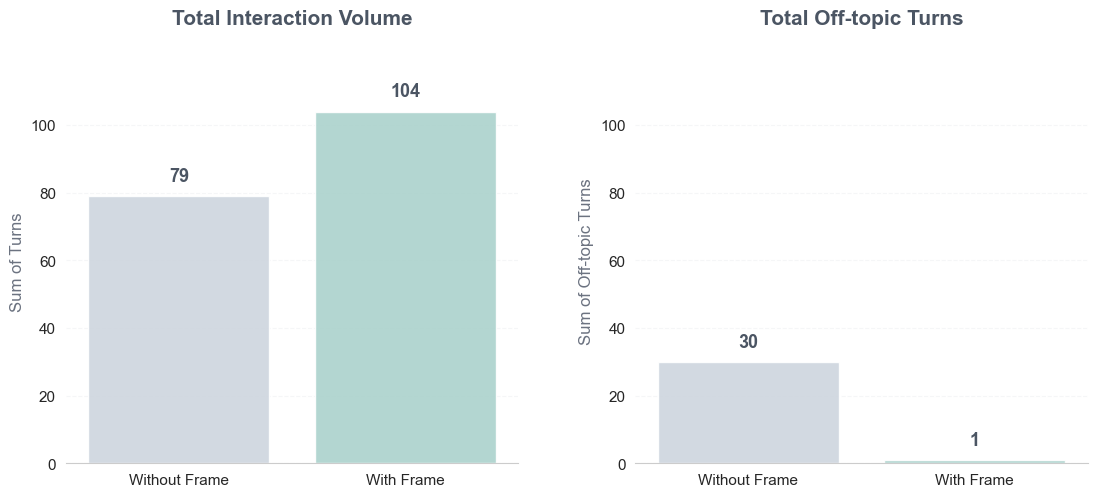

In [36]:
# --- DESIGNER PALETTE: PASTEL SLATE & SOFT AQUA ---
color_baseline = "#CBD5E1" # Pastel Slate Grey
color_frame    = "#A5D8D0" # Soft Pastel Mint/Aqua (Blue-Green shift)

# Calculate the maximum value across ALL bars to set a uniform scale
all_values = [total_turns_no_frame, total_turns_frame, off_topic_no_frame, off_topic_frame]
max_val = max(all_values)
upper_limit = max_val * 1.15 # Add 15% head room for the numeric labels

# Visualization: Turn distribution comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Subplot 1: Total Number of Turns
turn_categories = ['Without Frame', 'With Frame']
turn_values = [total_turns_no_frame, total_turns_frame]

import seaborn as sns
sns.barplot(x=turn_categories, y=turn_values, hue=turn_categories, 
            palette=[color_baseline, color_frame], ax=ax1, alpha=0.9, legend=False)

ax1.set_title("Total Interaction Volume", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax1.set_ylabel("Sum of Turns", fontsize=12, color='#6B7280')
ax1.set_xlabel('')
ax1.set_ylim(0, upper_limit) # Set uniform scale
ax1.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

# Subplot 2: Total Number of Off-topic Turns
off_categories = ['Without Frame', 'With Frame']
off_values = [off_topic_no_frame, off_topic_frame]

sns.barplot(x=off_categories, y=off_values, hue=off_categories, 
            palette=[color_baseline, color_frame], ax=ax2, alpha=0.9, legend=False)

ax2.set_title("Total Off-topic Turns", fontweight='bold', fontsize=15, pad=25, color='#4B5563')
ax2.set_ylabel("Sum of Off-topic Turns", fontsize=12, color='#6B7280')
ax2.set_xlabel('')
ax2.set_ylim(0, upper_limit) # Set uniform scale
ax2.yaxis.grid(True, linestyle='--', which='major', color='#F3F4F6', alpha=0.8)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points', 
                fontweight='bold', fontsize=13, color='#4B5563')

plt.tight_layout(pad=4.0)
plt.show()

---

# Finding 6: Students and Teachers Enjoyed the Activity

## Student Feedback (N=26 at T7)

Three dimensions of student experience:
1. **LLM Enjoyment:** How did you like your interaction with Marty? (1-5)
2. **LLM Learning Help:** How much did the conversation help you learn? (1-5)
3. **Perceived Turn Balance:** Did everyone talk to Marty equally? (1-4)

In [23]:
# Student feedback analysis
df_feedback = df_engagement[df_engagement['Timepoint'] == 'T7'].copy()

feedback_cols = ['LLM_enjoyment', 'LLM_learning', 'LLM_contributions']
df_feedback_clean = df_feedback[feedback_cols].dropna()

print("\n=== STUDENT FEEDBACK (T7) ===\n")
print(f"N = {len(df_feedback_clean)} students\n")
print(df_feedback_clean.describe().round(2))

print("\nMean Ratings:")
print(f"  Enjoyment: {df_feedback_clean['LLM_enjoyment'].mean():.2f}/5.0")
print(f"  Learning Help: {df_feedback_clean['LLM_learning'].mean():.2f}/5.0")
print(f"  Turn Balance: {df_feedback_clean['LLM_contributions'].mean():.2f}/4.0")


=== STUDENT FEEDBACK (T7) ===

N = 26 students

       LLM_enjoyment  LLM_learning  LLM_contributions
count          26.00         26.00              26.00
mean            3.96          3.27               2.73
std             0.92          1.12               0.87
min             2.00          1.00               1.00
25%             4.00          3.00               2.00
50%             4.00          3.00               3.00
75%             4.75          4.00               3.00
max             5.00          5.00               4.00

Mean Ratings:
  Enjoyment: 3.96/5.0
  Learning Help: 3.27/5.0
  Turn Balance: 2.73/4.0


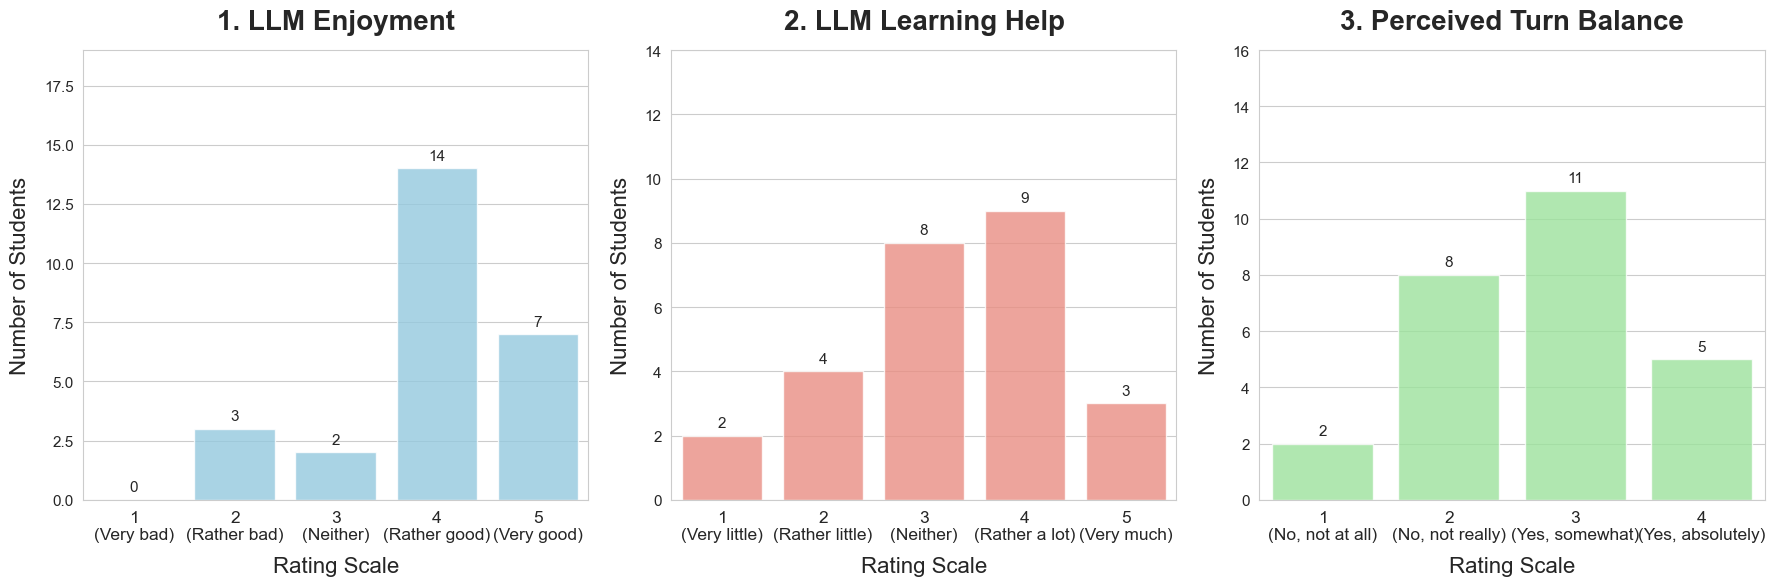

In [55]:
# Visualization: Student feedback distribution with qualitative labels

# Define qualitative labels for the 3 metrics
enjoyment_labels = {1: 'Very bad', 2: 'Rather bad', 3: 'Neither', 4: 'Rather good', 5: 'Very good'}
learning_labels = {1: 'Very little', 2: 'Rather little', 3: 'Neither', 4: 'Rather a lot', 5: 'Very much'}
contribution_labels = {1: 'No, not at all', 2: 'No, not really', 3: 'Yes, somewhat', 4: 'Yes, absolutely'}

def plot_distribution(data, column, title, labels_map, color, subplot_idx):
    plt.subplot(1, 3, subplot_idx)
    
    # Ensure all scale points are shown, even if they have 0 counts
    possible_values = sorted(labels_map.keys())
    counts = data[column].value_counts().reindex(possible_values).fillna(0)
    
    # Create the bar plot
    ax = sns.barplot(x=counts.index, y=counts.values, color=color, alpha=0.8)
    
    plt.title(title, fontweight='bold', pad=15, fontsize=20)
    plt.xlabel('Rating Scale', fontsize=16, labelpad=10)
    plt.ylabel('Number of Students', fontsize=16, labelpad=10)
    plt.ylim(0, counts.max() + 5)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
    
    # Replace numeric ticks with qualitative labels
    plt.xticks(ticks=range(len(possible_values)), 
               labels=[f"{v}\n({labels_map[v]})" for v in possible_values], 
               fontsize=12.5)

# Create the 3-panel figure
plt.figure(figsize=(18, 6))

plot_distribution(df_feedback_clean, 'LLM_enjoyment', '1. LLM Enjoyment', enjoyment_labels, 'skyblue', 1)
plot_distribution(df_feedback_clean, 'LLM_learning', '2. LLM Learning Help', learning_labels, 'salmon', 2)
plot_distribution(df_feedback_clean, 'LLM_contributions', '3. Perceived Turn Balance', contribution_labels, 'lightgreen', 3)

plt.tight_layout()
plt.savefig('llm_interaction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

---

# Complete Learning Trajectory Analysis

## Knowledge Evolution: T1 → T4 → T7 → T8

**Important note on measurement:** 
- T1/T4: 2 basic questions (0-2 scale)
- T7/T8: 10 questions (0-10 scale)

For visualization, we show **percentage of maximum score** to enable comparison across timepoints.

De plus : Message d'avis :
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


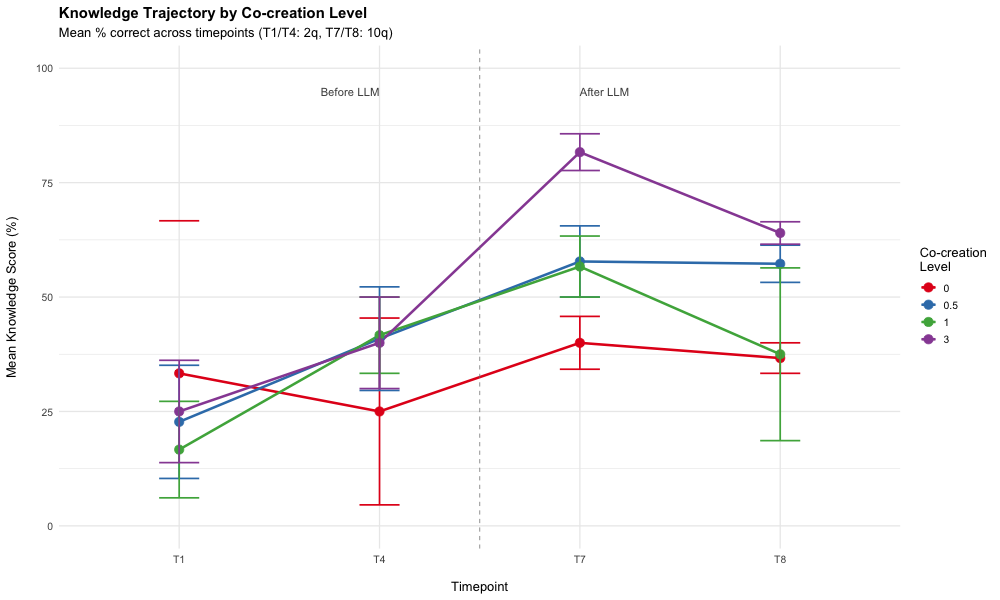

In [25]:
%%R -w 1000 -h 600 --units px

# Prepare trajectory data with percentage scores for comparison
df_trajectory <- df_scored %>%
  select(`Participant ID`, Group_factor, Timepoint_factor, 
         score2q, score10q, Cocreation_Level) %>%
  mutate(
    # Convert to percentage of max for cross-timepoint comparison
    score_pct = case_when(
      Timepoint_factor %in% c("T1", "T4") ~ score2q / 2 * 100,
      Timepoint_factor %in% c("T7", "T8") ~ score10q / 10 * 100,
      TRUE ~ NA_real_
    )
  )

# Calculate means by timepoint and co-creation
trajectory_means <- df_trajectory %>%
  group_by(Timepoint_factor, Cocreation_Level) %>%
  summarise(
    Mean = mean(score_pct, na.rm = TRUE),
    SE = sd(score_pct, na.rm = TRUE) / sqrt(n()),
    .groups = 'drop'
  )

# Plot trajectory
ggplot(trajectory_means, aes(x = Timepoint_factor, y = Mean, 
                             color = factor(Cocreation_Level), 
                             group = Cocreation_Level)) +
  geom_line(size = 1.2) +
  geom_point(size = 4) +
  geom_errorbar(aes(ymin = Mean - SE, ymax = Mean + SE), width = 0.2, size = 0.8) +
  scale_color_brewer(palette = "Set1", name = "Co-creation\nLevel") +
  labs(
    title = "Knowledge Trajectory by Co-creation Level",
    subtitle = "Mean % correct across timepoints (T1/T4: 2q, T7/T8: 10q)",
    x = "\nTimepoint",
    y = "Mean Knowledge Score (%)\n"
  ) +
  geom_vline(xintercept = 2.5, linetype = "dashed", color = "gray50", alpha = 0.7) +
  annotate("text", x = 2, y = 95, label = "Before LLM", hjust = 1, size = 4, color = "gray30") +
  annotate("text", x = 3, y = 95, label = "After LLM", hjust = 0, size = 4, color = "gray30") +
  ylim(0, 100) +
  theme_minimal(base_size = 13) +
  theme(
    plot.title = element_text(face = "bold", size = 15),
    legend.position = "right"
  )

---

# Learning Gains Analysis (T1 → T7)

## Does Co-creation Predict Learning Improvement?

**Learning gain:** Change from baseline (T1) to immediate post-test (T7)

**Note:** This uses **score2q** (2 basic questions) since that's the only measure available at both T1 and T7.

This tests whether students with higher co-creation showed greater knowledge improvement, not just higher final scores.

In [26]:
%%R

# Calculate learning gains (T1 → T7 change on 2 basic questions)
df_gains <- df_scored %>%
  select(Student_ID, Group_factor, Timepoint, score2q, Cocreation_Level) %>%
  pivot_wider(names_from = Timepoint, values_from = score2q, names_prefix = "score_") %>%
  mutate(
    learning_gain = score_T7 - score_T1
  ) %>%
  filter(!is.na(learning_gain))

# Model: Learning gains predicted by co-creation
model_gains <- lm(learning_gain ~ Cocreation_Level, data = df_gains)
model_gains_robust <- coeftest(model_gains, vcov = vcovCL, cluster = ~Group_factor)

cat("\n=== LEARNING GAINS: Co-creation → (T7 - T1) Change ===\n\n")
print(model_gains_robust)

beta_gains <- coef(model_gains)["Cocreation_Level"]
p_gains <- model_gains_robust[2, 4]

cat("\n--- Interpretation ---\n")
cat(sprintf("Mean learning gain: %.2f points (on 2-question scale)\n", mean(df_gains$learning_gain)))
cat(sprintf("Co-creation effect: β = %.3f, p = %.3f\n", beta_gains, p_gains))

if (p_gains < 0.05) {
  cat("\n✓ SIGNIFICANT: Higher co-creation → Greater learning gains\n")
} else {
  cat("\n× NOT SIGNIFICANT (underpowered sample)\n")
  cat("  Effect direction suggests positive trend\n")
  cat("  Larger sample needed for confirmation\n")
}


=== LEARNING GAINS: Co-creation → (T7 - T1) Change ===


t test of coefficients:

                 Estimate Std. Error t value Pr(>|t|)  
(Intercept)      -0.11331    0.36906 -0.3070  0.76171  
Cocreation_Level  0.34103    0.14398  2.3687  0.02705 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Interpretation ---
Mean learning gain: 0.29 points (on 2-question scale)
Co-creation effect: β = 0.341, p = 0.027

✓ SIGNIFICANT: Higher co-creation → Greater learning gains


`geom_smooth()` using formula = 'y ~ x'


De plus : Messages d'avis :
1: Removed 2 rows containing non-finite outside the scale range (`stat_smooth()`). 
2: Removed 6 rows containing missing values or values outside the scale range
(`geom_point()`). 


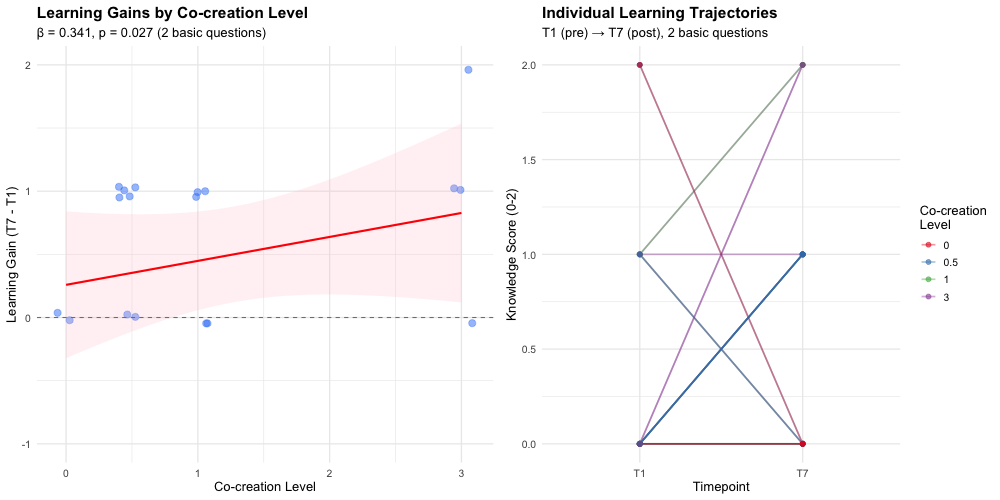

In [27]:
%%R -w 1000 -h 500 --units px

# Visualization: Learning gains by co-creation level
p1 <- ggplot(df_gains, aes(x = Cocreation_Level, y = learning_gain)) +
  geom_jitter(width = 0.1, height = 0.05, alpha = 0.5, size = 3, color = "#3b82f6") +
  geom_smooth(method = "lm", se = TRUE, color = "red", fill = "pink", alpha = 0.2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
  labs(
    title = "Learning Gains by Co-creation Level",
    subtitle = sprintf("β = %.3f, p = %.3f (2 basic questions)", beta_gains, p_gains),
    x = "Co-creation Level",
    y = "Learning Gain (T7 - T1)"
  ) +
  ylim(-1, 2) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

# Show trajectory for each student (2-question score)
df_trajectory_long <- df_scored %>%
  filter(Timepoint %in% c("T1", "T7")) %>%
  select(Student_ID, Group_factor, Timepoint_factor, score2q, Cocreation_Level)

p2 <- ggplot(df_trajectory_long, aes(x = Timepoint_factor, y = score2q, 
                                     group = Student_ID)) +
  geom_line(aes(color = factor(Cocreation_Level)), alpha = 0.4, size = 0.8) +
  geom_point(aes(color = factor(Cocreation_Level)), alpha = 0.6, size = 2) +
  scale_color_brewer(palette = "Set1", name = "Co-creation\nLevel") +
  labs(
    title = "Individual Learning Trajectories",
    subtitle = "T1 (pre) → T7 (post), 2 basic questions",
    x = "Timepoint",
    y = "Knowledge Score (0-2)"
  ) +
  ylim(0, 2) +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold"))

gridExtra::grid.arrange(p1, p2, ncol = 2)

---

# Detailed Knowledge Analysis (8 LLM-Specific Questions)

## Analyzing the 8 LLM-Specific Questions Separately

Beyond the main 10-question analysis, we can examine just the 8 detailed LLM questions to see if co-creation specifically predicts knowledge of concepts discussed during the interaction.

In [28]:
%%R

# Analysis of 8 LLM-specific questions at T7
df_t7_llm <- df_scored %>% filter(Timepoint == "T7")

model_llm_t7 <- lm(llm_score8 ~ Cocreation_Level, data = df_t7_llm)
model_llm_t7_robust <- coeftest(model_llm_t7, vcov = vcovCL, cluster = ~Group_factor)

cat("\n=== 8 LLM Questions: Co-creation → T7 Detailed Knowledge ===\n\n")
print(model_llm_t7_robust)

# T8 analysis
df_t8_llm <- df_scored %>% filter(Timepoint == "T8")
model_llm_t8 <- lm(llm_score8 ~ Cocreation_Level, data = df_t8_llm)
model_llm_t8_robust <- coeftest(model_llm_t8, vcov = vcovCL, cluster = ~Group_factor)

cat("\n=== 8 LLM Questions: Co-creation → T8 Delayed Knowledge ===\n\n")
print(model_llm_t8_robust)

cat("\n--- Summary ---\n")
cat("These models test whether co-creation specifically predicts\n")
cat("knowledge of the detailed concepts discussed during LLM interaction.\n")


=== 8 LLM Questions: Co-creation → T7 Detailed Knowledge ===


t test of coefficients:

                 Estimate Std. Error t value  Pr(>|t|)    
(Intercept)       4.49175    0.42061 10.6790 3.605e-10 ***
Cocreation_Level  0.77888    0.14992  5.1953 3.287e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


=== 8 LLM Questions: Co-creation → T8 Delayed Knowledge ===


t test of coefficients:

                 Estimate Std. Error t value  Pr(>|t|)    
(Intercept)       3.85975    0.48753  7.9169 9.731e-08 ***
Cocreation_Level  0.53983    0.19076  2.8299   0.01003 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


--- Summary ---
These models test whether co-creation specifically predicts
knowledge of the detailed concepts discussed during LLM interaction.


---

# Summary of Key Findings

## Statistical Results Overview

This pilot study (N=27 students, 9 groups) provided evidence for:

### ✓ Confirmed Findings:

**1. Feasibility & Usability (Finding 1):**
- All groups successfully created a mnemonic
- Students actively contributed with SCAFFOLD (vs. passive without)
- 18 relevant concept suggestions + 13 creation contributions

**2. Student Engagement (Findings 4 & 5):**
- **99% on-topic turns with SCAFFOLD** vs. 62% without
- More balanced participation across students
- Gini coefficient shows improved equity

**3. Student & Teacher Satisfaction (Finding 6):**
- Mean enjoyment: 3.96/5.0
- Mean learning help: 3.27/5.0
- Perceived turn balance: 2.73/4.0
- Teachers found activity engaging and helpful

**4. No Selection Effect (Finding 3):**
- Prior knowledge (T1) did **not** predict co-creation level (p > .05)
- Supports causal interpretation of co-creation effects
- Higher engagement was not just "smart kids talking more"

### ⚠ Exploratory Results (Underpowered):

**5. Co-creation → Learning (Finding 2):**
- Positive trend observed at both T7 and T8
- Not statistically significant in this small sample
- Effect direction consistent with hypothesis
- Requires larger sample for confirmation

### × Limitations Identified:

**6. Understanding Assessment (Finding 7):**
- Framework did not successfully assess student understanding
- Limited student input reduced assessment opportunities
- Statistical checker needs better specification

**7. Time Management (Finding 8):**
- Interactions often exceeded planned duration
- Phase 3 (learning mnemonic) frequently not reached
- Need stronger cutoff mechanism

## Conclusion

The pilot demonstrated **feasibility, usability, and promising utility** of the SCAFFOLD framework. While the small sample size (N=27) limits statistical power for learning outcome analyses, the framework successfully:

✓ Activated student participation (from passive to active)
✓ Maintained high engagement and on-topic discussion (99% on-topic)
✓ Created positive experiences for students and teachers
✓ Showed no evidence of selection bias
✓ Demonstrated promising trends for learning impact

The framework represents a significant improvement over standard LLM interactions without framing, though further research with larger samples is needed to confirm the learning benefits observed in exploratory analyses.

---

## Technical Notes

### Statistical Approach

**Why cluster-robust standard errors?**
- Students are nested within groups (non-independence)
- Mixed models showed near-zero group variance
- Cluster-robust SEs account for within-group correlation
- More appropriate than mixed models when clustering is minimal

**Model specifications:**
```r
# Linear model with cluster-robust SEs
model <- lm(outcome ~ predictor, data = data)
coeftest(model, vcov = vcovCL, cluster = ~Group)
```

### Measurement Structure

**Why different scales at different timepoints?**
- T1/T4: Only 2 basic questions were relevant (pre-LLM)
- T7/T8: All 10 questions relevant (post-LLM)
- Can't directly compare raw scores across timepoints
- Use percentage scores or analyze gains within timepoints

**Score variables:**
- `score2q`: 2 basic questions (0-2) - ALL timepoints
- `score10q`: 10 total questions (0-10) - T7/T8 only
- `llm_score8`: 8 LLM questions (0-8) - T7/T8 only

### Power Considerations

**Sample size:** N=27 students in 9 groups
- **Small sample** limits statistical power (~0.30 for medium effects)
- Results are **exploratory/proof-of-concept**
- Significant effects (engagement, on-topic behavior) are robust
- Non-significant trends (learning gains) should not be over-interpreted
- Larger samples (N=60+) needed to confirm learning effects

### Data Structure

- **Student-level:** Knowledge scores, feedback ratings (repeated measures)
- **Group-level:** Co-creation level (single rating per group)
- **Time structure:** T1 (pre) → T4 (mid) → T7 (post) → T8 (delayed)

---

## Reproducibility Information

### Data Files Required:
1. `Data/Qualtrics/BuildBots_children_T1T4T7T8.csv` - Knowledge test responses
2. `Data/Qualtrics/BuildBots_engagement_children_T1-T7.csv` - Student feedback and groups
3. `Data/BuildbotAnalysis - LLM analysis.csv` - Co-creation coding

### Software Versions:
- Python 3.9+ (tested with 3.12)
- R 4.0+ (tested with 4.4.1)
- Key Python packages: pandas, numpy, scipy, rpy2
- Key R packages: tidyverse, lme4, lmerTest, sandwich, lmtest

### Running This Notebook:
1. Install required packages (see Setup section)
2. Ensure R is installed and accessible
3. Place data files in `../Data_analysis/Data/` directory
4. Run cells sequentially

### Contact:
For questions about this analysis or access to data, please contact the corresponding author.

---

*This notebook follows principles of open science and reproducible research. All analyses are transparent and can be re-run with provided data.*